In [1]:
!pip install wordcloud matplotlib seaborn nltk pandas numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

print('All libraries loaded!')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/wagueacarinefongang/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/wagueacarinefongang/nltk_data...


All libraries loaded!


[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Loading the dataset
df = pd.read_csv('tweets.csv')

print('Dataset loaded!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded!
Shape: (11370, 5)


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [5]:
# Basic information about the dataset
print('DATASET INFORMATION:')
print(f'Total tweets: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum())

DATASET INFORMATION:
Total tweets: 11370
Columns: ['id', 'keyword', 'location', 'text', 'target']

Missing values:
id             0
keyword        0
location    3418
text           0
target         0
dtype: int64


Label Distribution:
Non-disaster tweets (0): 9256
Disaster tweets (1): 2114

Percentage disaster: 18.6%
Percentage non-disaster: 81.4%


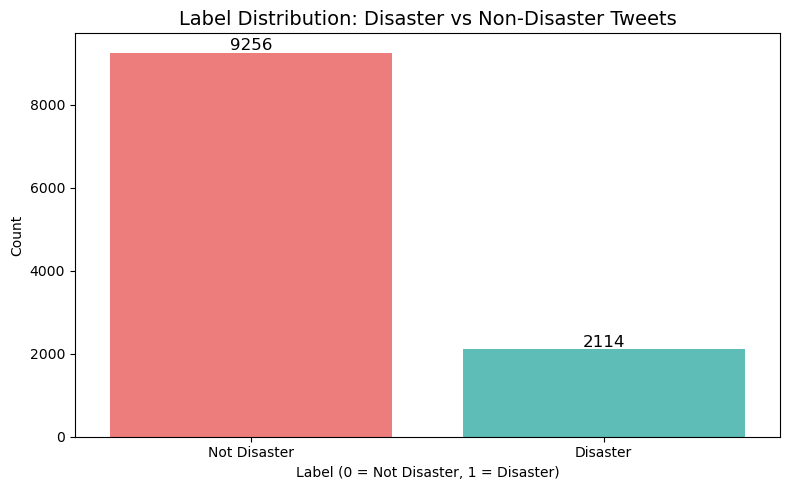

In [6]:
# Count disaster vs non-disaster tweets
label_counts = df['target'].value_counts()
print('Label Distribution:')
print(f'Non-disaster tweets (0): {label_counts[0]}')
print(f'Disaster tweets (1): {label_counts[1]}')
print(f'\nPercentage disaster: {label_counts[1]/len(df)*100:.1f}%')
print(f'Percentage non-disaster: {label_counts[0]/len(df)*100:.1f}%')

# Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Label Distribution: Disaster vs Non-Disaster Tweets', fontsize=14)
plt.xlabel('Label (0 = Not Disaster, 1 = Disaster)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Disaster', 'Disaster'])
for i, count in enumerate(label_counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
def clean_text(text):
    text = str(text).lower()                          
    # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        
    # remove URLs
    text = re.sub(r'@\w+', '', text)                  
    # remove mentions
    text = re.sub(r'#', '', text)                     
    # remove hashtag symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)           
    # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()          
    # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)
print('Text cleaned!')
print('\nExample:')
print('Original:', df['text'][0])
print('Cleaned:', df['clean_text'][0])

Text cleaned!

Example:
Original: Communal violence in Bhainsa, Telangana. "Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…
Cleaned: communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ablaze


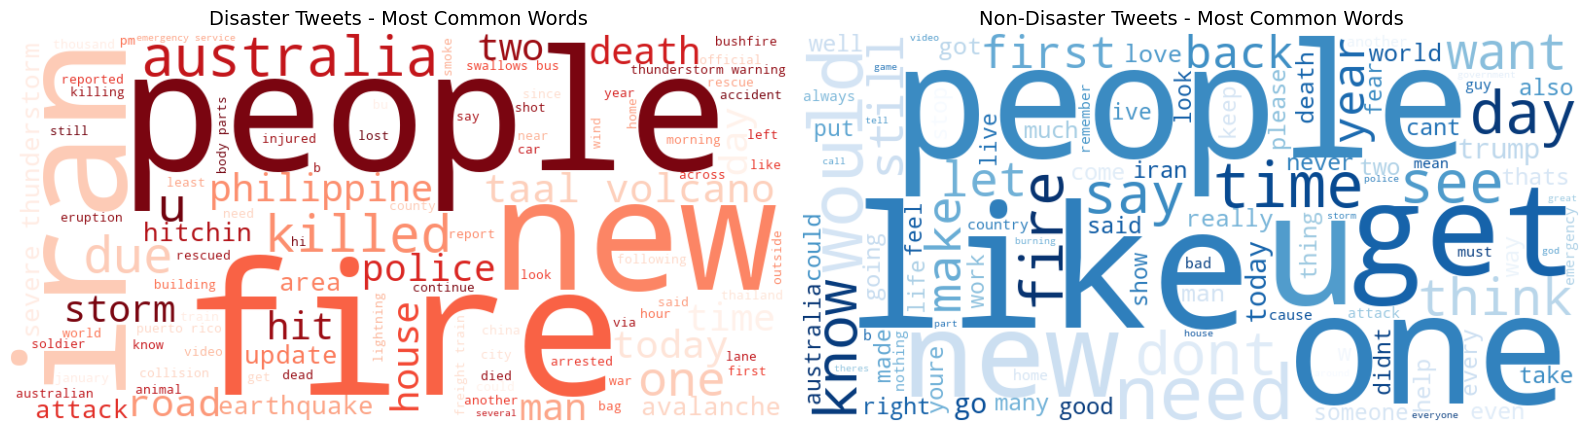

In [9]:
# Add 'amp' to stopwords
stop_words.add('amp')
stop_words.add('th')
stop_words.add('im')

# Regenerate the word clouds
disaster_text = ' '.join(df[df['target'] == 1]['clean_text'])
non_disaster_text = ' '.join(df[df['target'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_disaster = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    stopwords=stop_words,
    max_words=100
).generate(disaster_text)

axes[0].imshow(wc_disaster, interpolation='bilinear')
axes[0].set_title('Disaster Tweets - Most Common Words', fontsize=14)
axes[0].axis('off')

wc_non_disaster = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    stopwords=stop_words,
    max_words=100
).generate(non_disaster_text)

axes[1].imshow(wc_non_disaster, interpolation='bilinear')
axes[1].set_title('Non-Disaster Tweets - Most Common Words', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

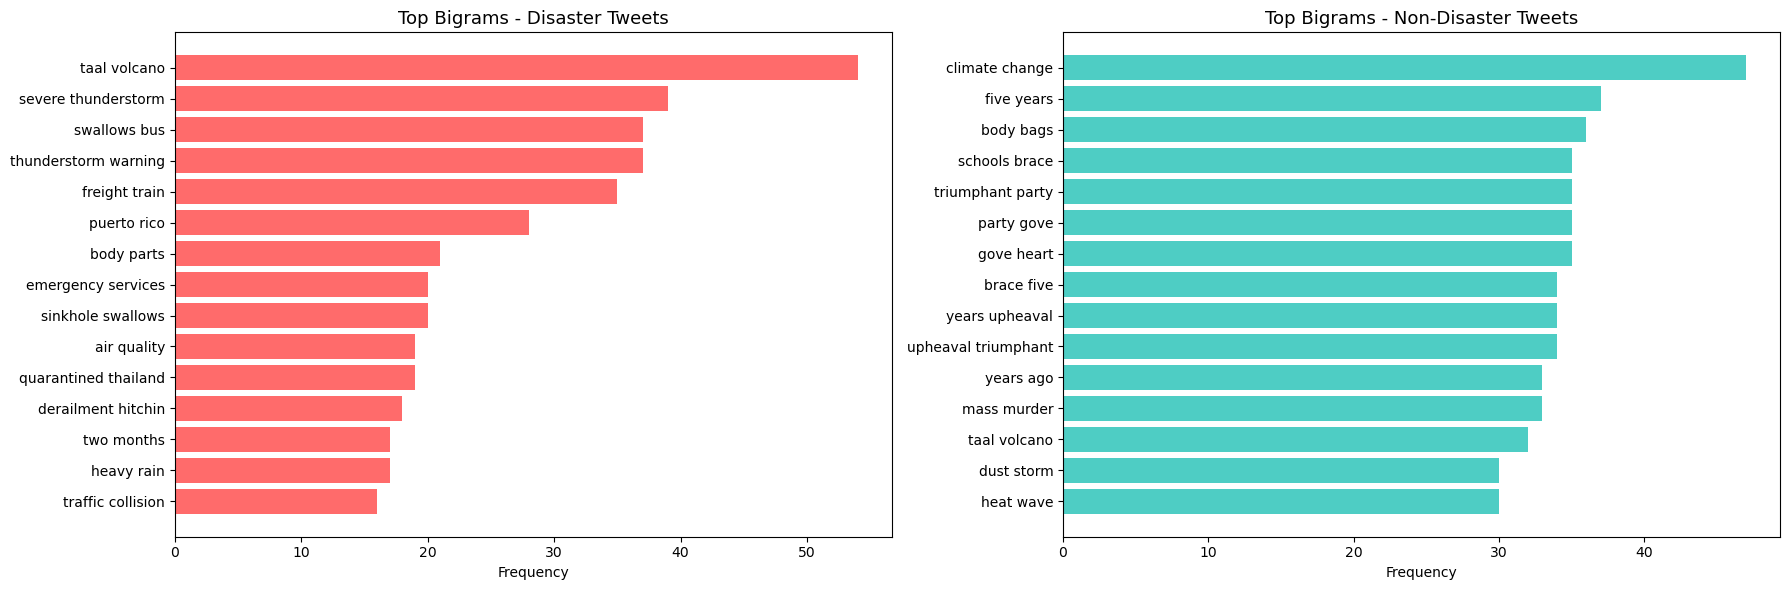

In [10]:
def get_top_ngrams(text, n, top_k=15):
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    n_grams = list(ngrams(words, n))
    return Counter(n_grams).most_common(top_k)

# Get bigrams (2-word combinations)
disaster_bigrams = get_top_ngrams(disaster_text, 2)
non_disaster_bigrams = get_top_ngrams(non_disaster_text, 2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Disaster bigrams
labels, counts = zip(*disaster_bigrams)
labels = [' '.join(l) for l in labels]
axes[0].barh(labels[::-1], counts[::-1], color='#FF6B6B')
axes[0].set_title('Top Bigrams - Disaster Tweets', fontsize=13)
axes[0].set_xlabel('Frequency')

# Non-disaster bigrams
labels2, counts2 = zip(*non_disaster_bigrams)
labels2 = [' '.join(l) for l in labels2]
axes[1].barh(labels2[::-1], counts2[::-1], color='#4ECDC4')
axes[1].set_title('Top Bigrams - Non-Disaster Tweets', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

=== Tweet Length Stats ===

Disaster tweets:
count    2114.000000
mean       17.355724
std         4.589154
min         1.000000
25%        14.000000
50%        18.000000
75%        21.000000
max        29.000000
Name: tweet_length, dtype: float64

Non-disaster tweets:
count    9256.000000
mean       17.122839
std         5.699776
min         1.000000
25%        14.000000
50%        18.000000
75%        21.000000
max        32.000000
Name: tweet_length, dtype: float64


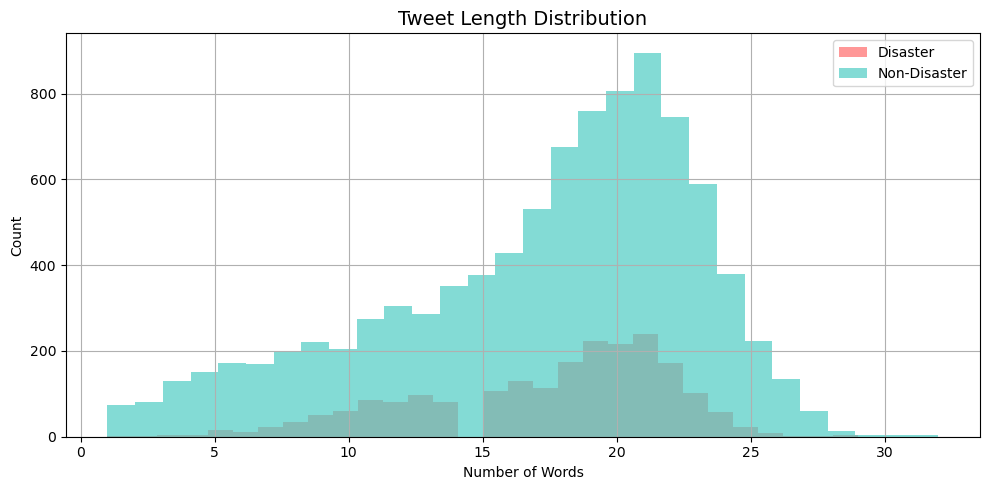

In [11]:
df['tweet_length'] = df['text'].apply(lambda x: len(str(x).split()))

print('=== Tweet Length Stats ===')
print('\nDisaster tweets:')
print(df[df['target']==1]['tweet_length'].describe())
print('\nNon-disaster tweets:')
print(df[df['target']==0]['tweet_length'].describe())

plt.figure(figsize=(10, 5))
df[df['target']==1]['tweet_length'].hist(bins=30, alpha=0.7, color='#FF6B6B', label='Disaster')
df[df['target']==0]['tweet_length'].hist(bins=30, alpha=0.7, color='#4ECDC4', label='Non-Disaster')
plt.title('Tweet Length Distribution', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
print('DATA EXPLORATION SUMMARY ')
print(f'Total tweets: {len(df)}')
print(f'Disaster tweets: {len(df[df["target"]==1])} ({len(df[df["target"]==1])/len(df)*100:.1f}%)')
print(f'Non-disaster tweets: {len(df[df["target"]==0])} ({len(df[df["target"]==0])/len(df)*100:.1f}%)')
print(f'\nAvg tweet length (disaster): {df[df["target"]==1]["tweet_length"].mean():.1f} words')
print(f'Avg tweet length (non-disaster): {df[df["target"]==0]["tweet_length"].mean():.1f} words')
print(f'\nMissing location data: {df["location"].isnull().sum()} tweets ({df["location"].isnull().sum()/len(df)*100:.1f}%)')
print(f'\nDataset is IMBALANCED:')
print(f'- Only 18.6% are disaster tweets')
print(f'- Will need to handle class imbalance when training models')

DATA EXPLORATION SUMMARY 
Total tweets: 11370
Disaster tweets: 2114 (18.6%)
Non-disaster tweets: 9256 (81.4%)

Avg tweet length (disaster): 17.4 words
Avg tweet length (non-disaster): 17.1 words

Missing location data: 3418 tweets (30.1%)

Dataset is IMBALANCED:
- Only 18.6% are disaster tweets
- Will need to handle class imbalance when training models


In [ ]:
import zipfile
import os


with zipfile.ZipFile('disaster-tweet-filtering-incident-tweets.zip', 'r') as zip_ref:
    zip_ref.extractall('zenodo_data')

# See what files are inside
for root, dirs, files in os.walk('zenodo_data'):
    for file in files:
        print(os.path.join(root, file))

zenodo_data/incident-tweets/transportation-glasgow-helicopter-crash-2013.ndjson
zenodo_data/incident-tweets/biological-mers-2014.ndjson
zenodo_data/incident-tweets/earthquake-nepal-2015.ndjson
zenodo_data/incident-tweets/biological-ebola-2014.ndjson
zenodo_data/incident-tweets/earthquake-guatemala-2012.ndjson
zenodo_data/incident-tweets/earthquake-chile-2013.ndjson
zenodo_data/incident-tweets/tornado-joplin-2011.ndjson
zenodo_data/incident-tweets/hurricane-pam-2015.ndjson
zenodo_data/incident-tweets/hurricane-irma-2017.ndjson
zenodo_data/incident-tweets/societal-boston-bombing-2013.ndjson
zenodo_data/incident-tweets/tornado-oklahoma-2013.ndjson
zenodo_data/incident-tweets/industrial-texas-explosion-2013.ndjson
zenodo_data/incident-tweets/industrial-savar-building-collapse-2013.ndjson
zenodo_data/incident-tweets/hurricane-pablo-2012.ndjson
zenodo_data/incident-tweets/hurricane-hagupit-2014.ndjson
zenodo_data/incident-tweets/earthquake-bohol-2013.ndjson
zenodo_data/incident-tweets/transp

In [14]:
import json

all_zenodo_tweets = []

for root, dirs, files in os.walk('zenodo_data'):
    for file in files:
        if file.endswith('.ndjson'):
            filepath = os.path.join(root, file)
            with open(filepath, 'r') as f:
                for line in f:
                    tweet = json.loads(line.strip())
                    all_zenodo_tweets.append(tweet)

df_zenodo = pd.DataFrame(all_zenodo_tweets)
print(f'Total Zenodo tweets: {len(df_zenodo)}')
print(f'Columns: {list(df_zenodo.columns)}')
df_zenodo.head()

Total Zenodo tweets: 163718
Columns: ['id', 'text', 'relevance']


,id,text,relevance
0,406553907700449280,terrible here in glasgow helicopter crashed in...,1
1,406555220513394688,helicopter 'crashes into pub in glasgow' <URL>...,1
2,406555392492462080,breaking: a helicopter has crashed in to the r...,1
3,406555799344136193,labour mp jim murphy says a helicopter has cra...,1
4,406556302643822592,anybody heard anything about a helicopter cras...,1


In [ ]:
# Checking the Zenodo label distribution
zenodo_counts = df_zenodo['relevance'].value_counts()
print('Zenodo Label Distribution:')
print(f'Relevant (1): {zenodo_counts[1]}')
print(f'Not Relevant (0): {zenodo_counts[0]}')
print(f'\nPercentage relevant: {zenodo_counts[1]/len(df_zenodo)*100:.1f}%')
print(f'Percentage not relevant: {zenodo_counts[0]/len(df_zenodo)*100:.1f}%')

# Renaming column to match Kaggle dataset
df_zenodo_clean = df_zenodo[['text', 'relevance']].rename(columns={'relevance': 'target'})

# Combining both datasets
df_kaggle_clean = df[['text', 'target']]
df_combined = pd.concat([df_kaggle_clean, df_zenodo_clean], ignore_index=True)

print(f'\nCOMBINED DATASET ')
print(f'Kaggle tweets: {len(df_kaggle_clean)}')
print(f'Zenodo tweets: {len(df_zenodo_clean)}')
print(f'Total combined: {len(df_combined)}')
print(f'\nCombined label distribution:')
print(df_combined['target'].value_counts())

Zenodo Label Distribution:
Relevant (1): 81859
Not Relevant (0): 81859

Percentage relevant: 50.0%
Percentage not relevant: 50.0%

=== COMBINED DATASET ===
Kaggle tweets: 11370
Zenodo tweets: 163718
Total combined: 175088

Combined label distribution:
target
0    91115
1    83973
Name: count, dtype: int64


In [16]:
df_combined.to_csv('combined_tweets.csv', index=False)
print('Combined dataset saved as combined_tweets.csv!')

Combined dataset saved as combined_tweets.csv!


In [18]:
def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                 # remove mentions
    text = re.sub(r'#\w+', '', text)                 # remove full hashtags
    text = re.sub(r'\burl\b', '', text)              # remove 'url' placeholder
    text = re.sub(r'\buser\b', '', text)             # remove 'user' placeholder
    text = re.sub(r'\bnumber\b', '', text)           # remove 'number' placeholder
    text = re.sub(r'\brepeat\b', '', text)           # remove 'repeat' placeholder
    text = re.sub(r'\bhashtag\b', '', text)          # remove 'hashtag' placeholder
    text = re.sub(r'\brt\b', '', text)               # remove retweet tag
    text = re.sub(r'\bvia\b', '', text)              # remove via
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()         # remove extra spaces
    return text

# Apply to Zenodo dataset
df_zenodo['clean_text'] = df_zenodo['text'].apply(clean_text_v2)

print('Cleaned!')
print('Original:', df_zenodo['text'][0])
print('Cleaned:', df_zenodo['clean_text'][0])

Cleaned!
Original: terrible here in glasgow helicopter crashed into roof of pub
Cleaned: terrible here in glasgow helicopter crashed into roof of pub


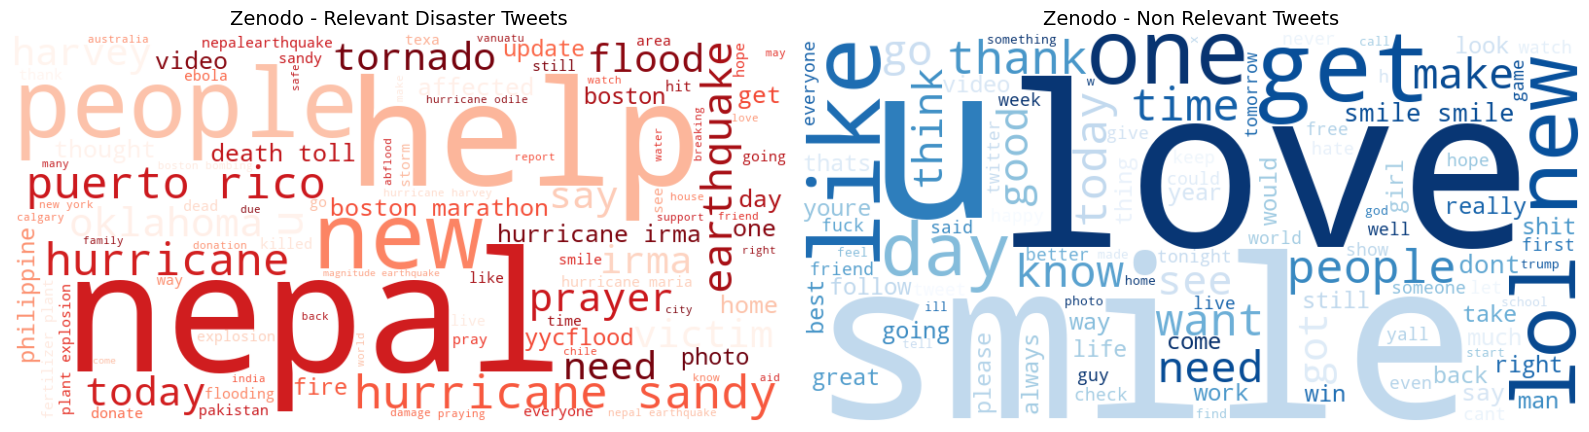

In [19]:
# Separate relevant and not relevant with clean text
zenodo_relevant = ' '.join(df_zenodo[df_zenodo['relevance'] == 1]['clean_text'])
zenodo_not_relevant = ' '.join(df_zenodo[df_zenodo['relevance'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc1 = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    stopwords=stop_words,
    max_words=100
).generate(zenodo_relevant)

axes[0].imshow(wc1, interpolation='bilinear')
axes[0].set_title('Zenodo - Relevant Disaster Tweets', fontsize=14)
axes[0].axis('off')

wc2 = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    stopwords=stop_words,
    max_words=100
).generate(zenodo_not_relevant)

axes[1].imshow(wc2, interpolation='bilinear')
axes[1].set_title('Zenodo - Non Relevant Tweets', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

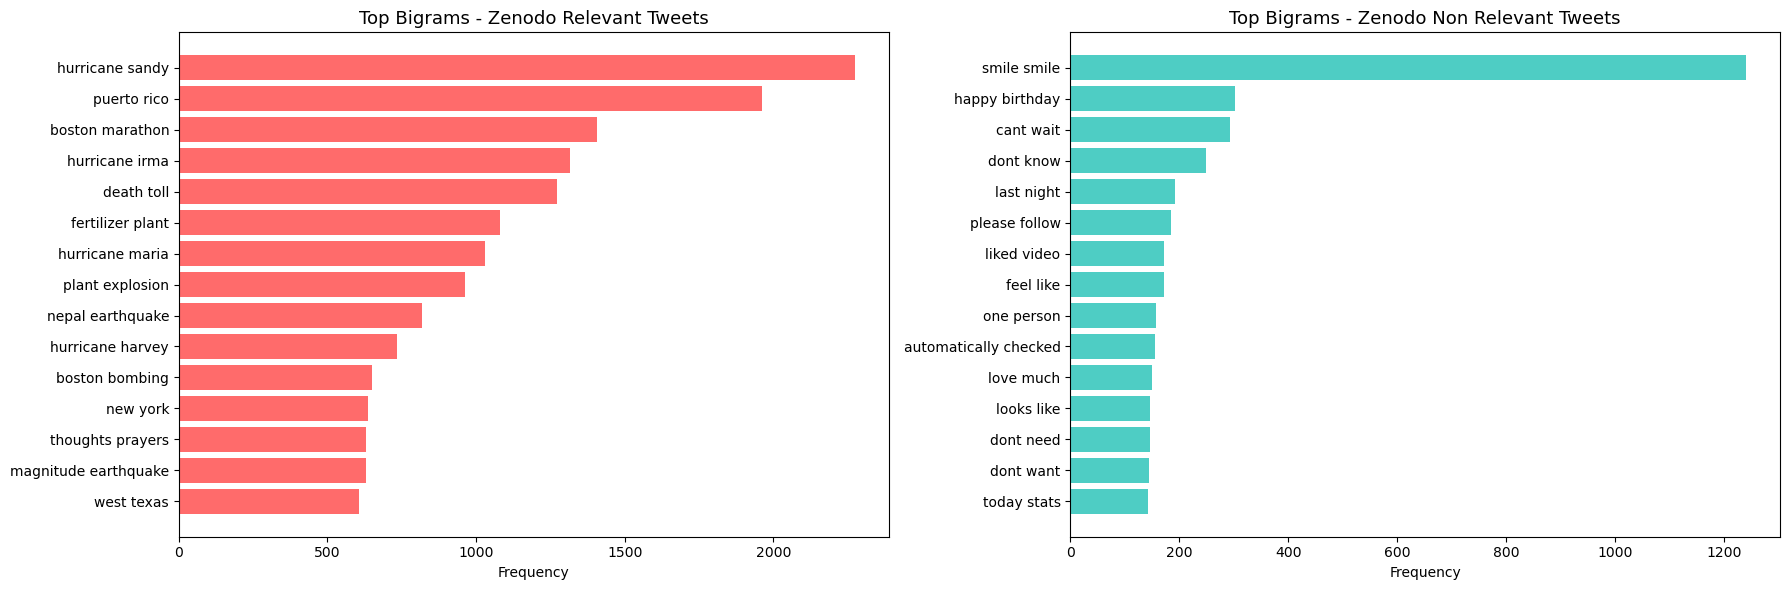

In [20]:
zenodo_bigrams_rel = get_top_ngrams(zenodo_relevant, 2)
zenodo_bigrams_nonrel = get_top_ngrams(zenodo_not_relevant, 2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

labels, counts = zip(*zenodo_bigrams_rel)
labels = [' '.join(l) for l in labels]
axes[0].barh(labels[::-1], counts[::-1], color='#FF6B6B')
axes[0].set_title('Top Bigrams - Zenodo Relevant Tweets', fontsize=13)
axes[0].set_xlabel('Frequency')

labels2, counts2 = zip(*zenodo_bigrams_nonrel)
labels2 = [' '.join(l) for l in labels2]
axes[1].barh(labels2[::-1], counts2[::-1], color='#4ECDC4')
axes[1].set_title('Top Bigrams - Zenodo Non Relevant Tweets', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

=== Zenodo Tweet Length Stats ===

Relevant tweets:
count    81859.000000
mean        16.623878
std          5.634689
min          1.000000
25%         13.000000
50%         17.000000
75%         21.000000
max        429.000000
Name: tweet_length, dtype: float64

Non-relevant tweets:
count    81859.000000
mean        13.622338
std          7.221544
min          1.000000
25%          8.000000
50%         13.000000
75%         19.000000
max         83.000000
Name: tweet_length, dtype: float64


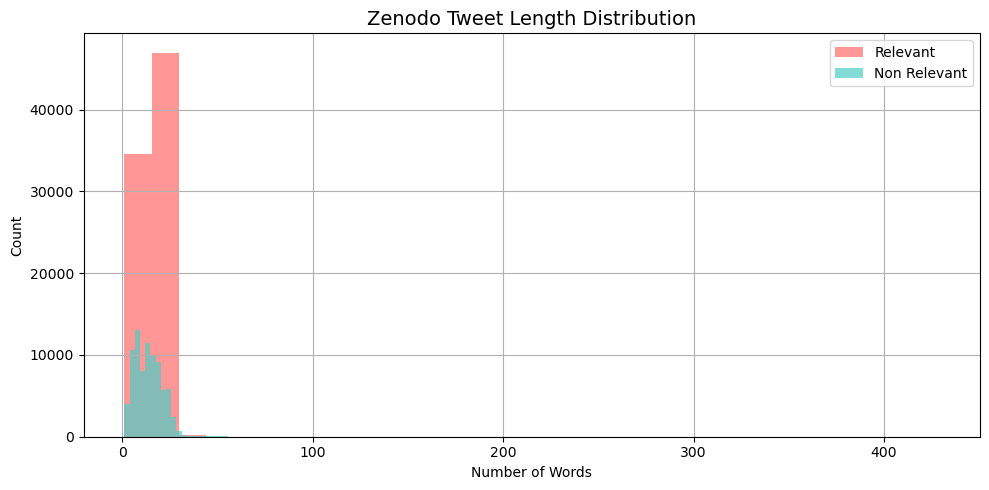

In [21]:
df_zenodo['tweet_length'] = df_zenodo['text'].apply(lambda x: len(str(x).split()))

print('=== Zenodo Tweet Length Stats ===')
print('\nRelevant tweets:')
print(df_zenodo[df_zenodo['relevance']==1]['tweet_length'].describe())
print('\nNon-relevant tweets:')
print(df_zenodo[df_zenodo['relevance']==0]['tweet_length'].describe())

plt.figure(figsize=(10, 5))
df_zenodo[df_zenodo['relevance']==1]['tweet_length'].hist(bins=30, alpha=0.7, color='#FF6B6B', label='Relevant')
df_zenodo[df_zenodo['relevance']==0]['tweet_length'].hist(bins=30, alpha=0.7, color='#4ECDC4', label='Non Relevant')
plt.title('Zenodo Tweet Length Distribution', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Save combined dataset
df_combined.to_csv('combined_tweets.csv', index=False)
print(f'Combined dataset saved!')
print(f'Total tweets: {len(df_combined)}')
print(f'Disaster tweets: {len(df_combined[df_combined["target"]==1])}')
print(f'Non-disaster tweets: {len(df_combined[df_combined["target"]==0])}')

Combined dataset saved!
Total tweets: 175088
Disaster tweets: 83973
Non-disaster tweets: 91115
